## Introduction

In this code, an overview of the available Sentinel-2 and Sentinel-3 images are given for a given Area Of Interest (AOI). As an example, the area of Brussels, Belgium is chosen.

This code is heavily based on this EOPF code [here](https://eopf-toolkit.github.io/eopf-101/04_eopf_and_stac/43_eopf_stac_connection.html).

In [36]:
import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt
import xarray as xr
import rioxarray as rio
from dask.distributed import Client as DaskClient
from pystac import MediaType
from pystac_client import Client
from datetime import datetime

Here, you can read in a Geojson file for the Brussels area, Belgium, for the first time. Please uncomment this line:

In [37]:
## brussels_file_path = 'https://github.com/EllenB/eopf/releases/download/data/brussels_dissolved.geojson'

In [38]:
## Please uncomment this if for the first time you want to download
## in your work environment
## Your area of interest.
# !wget -O brussels_dissolved.geojson \
# $brussels_file_path

<Axes: >

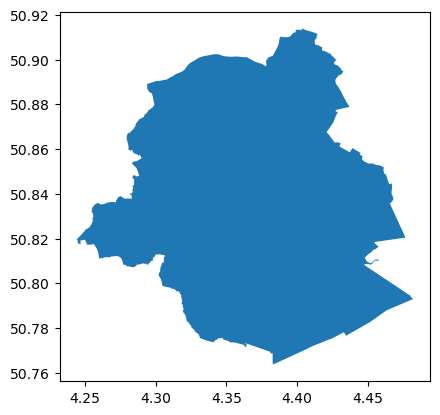

In [39]:
gdf = gpd.read_file('brussels_dissolved.geojson')
gdf.plot()

In [40]:
## Code obtained from:
## https://eopf-toolkit.github.io/eopf-101/04_eopf_and_stac/43_eopf_stac_connection.html
eopf_catalog = Client.open(url="https://stac.core.eopf.eodc.eu/")
## eopf_catalog

Print the collections in the catalogue:

In [41]:
for collection in eopf_catalog.get_all_collections():
        print(collection.id)

sentinel-2-l2a
sentinel-1-l1-grd
sentinel-3-slstr-l2-lst
sentinel-3-slstr-l2-frp
sentinel-3-olci-l2-lfr
sentinel-3-olci-l2-lrr
sentinel-3-olci-l1-efr
sentinel-1-l2-ocn
sentinel-3-slstr-l1-rbt
sentinel-2-l1c
sentinel-1-l1-slc
sentinel-3-olci-l1-err


In [42]:
# Set parameters:
period = "2025-01-01/2025-12-31"

# https://pystac-client.readthedocs.io/en/latest/tutorials/item-search-intersects.html
aoi = gdf.geometry.iloc[0].__geo_interface__

## Sentinel-2 search

In [43]:
items_s2 = eopf_catalog.search(
    collections='sentinel-2-l2a',
    intersects=aoi,
    datetime=period
   ).item_collection()

/opt/conda/lib/python3.12/site-packages/pystac/item.py:482: DeprecatedWarning: The item 'S2C_MSIL2A_20251217T104451_N0511_R008_T31UFS_20251217T144413' is deprecated.
  warnings.warn(
/opt/conda/lib/python3.12/site-packages/pystac/item.py:482: DeprecatedWarning: The item 'S2C_MSIL2A_20251217T104451_N0511_R008_T31UES_20251217T144413' is deprecated.
  warnings.warn(
/opt/conda/lib/python3.12/site-packages/pystac/item.py:482: DeprecatedWarning: The item 'S2A_MSIL2A_20251102T105231_N0511_R051_T31UFS_20251102T144301' is deprecated.
  warnings.warn(
/opt/conda/lib/python3.12/site-packages/pystac/item.py:482: DeprecatedWarning: The item 'S2B_MSIL2A_20251102T104109_N0511_R008_T31UES_20251102T112516' is deprecated.
  warnings.warn(
/opt/conda/lib/python3.12/site-packages/pystac/item.py:482: DeprecatedWarning: The item 'S2C_MSIL2A_20251031T105221_N0511_R051_T31UFS_20251031T144221' is deprecated.
  warnings.warn(
/opt/conda/lib/python3.12/site-packages/pystac/item.py:482: DeprecatedWarning: The it

The warnings show that that these data are no longer available.

In [44]:
print(f'There are {len(items_s2)} items in the collection')

There are 160 items in the collection


In [45]:
# for item in items_s2:
#     print(item)

In [46]:
items_s2[1]

<Item id=S2B_MSIL2A_20251225T105359_N0511_R051_T31UFS_20251225T130829>

We can filter a little more. Sometimes, we need to visualise first and get an idea of the Sentinel-2 tiles that overlap with our area. 

Filter now with less cloud cover, enough data coverage and the 31UES tile:

In [47]:
filters = {
    "eo:cloud_cover":{"lt":10},
}

In [48]:
items_s2_filtered = eopf_catalog.search(
    collections='sentinel-2-l2a',
    intersects=aoi,
    query=filters,
    datetime=period).item_collection()

In [49]:
print(f'There are {len(items_s2_filtered)} items in the S2-collection')

There are 21 items in the S2-collection


In [50]:
for item in items_s2_filtered:
  print(item)

<Item id=S2B_MSIL2A_20251225T105359_N0511_R051_T31UFS_20251225T130829>
<Item id=S2B_MSIL2A_20251225T105359_N0511_R051_T31UES_20251225T130829>
<Item id=S2B_MSIL2A_20251215T105349_N0511_R051_T31UFS_20251215T130426>
<Item id=S2C_MSIL2A_20251107T104251_N0511_R008_T31UES_20251107T142320>
<Item id=S2A_MSIL2A_20251030T104211_N0511_R008_T31UES_20251030T121715>
<Item id=S2C_MSIL2A_20250928T103831_N0511_R008_T31UES_20250928T161815>
<Item id=S2C_MSIL2A_20250630T104041_N0511_R008_T31UFS_20250630T161206>
<Item id=S2A_MSIL2A_20250516T104651_N0511_R051_T31UFS_20250516T153604>
<Item id=S2B_MSIL2A_20250516T103619_N0511_R008_T31UFS_20250516T132446>
<Item id=S2B_MSIL2A_20250516T103619_N0511_R008_T31UES_20250516T132446>
<Item id=S2A_MSIL2A_20250513T104041_N0511_R008_T31UFS_20250513T143716>
<Item id=S2A_MSIL2A_20250513T104041_N0511_R008_T31UES_20250513T143716>
<Item id=S2C_MSIL2A_20250511T103641_N0511_R008_T31UES_20250511T132601>
<Item id=S2C_MSIL2A_20250501T104041_N0511_R008_T31UES_20250501T161558>
<Item 

In [51]:
## If you change the index, you can have a quick look at what is in these files
items_s2_filtered[1]

<Item id=S2B_MSIL2A_20251225T105359_N0511_R051_T31UES_20251225T130829>

In [52]:
## Show the preview:
items_s2_filtered[1].assets.keys()

dict_keys(['SR_10m', 'SR_20m', 'SR_60m', 'AOT_10m', 'B01_20m', 'B02_10m', 'B03_10m', 'B04_10m', 'B05_20m', 'B06_20m', 'B07_20m', 'B08_10m', 'B09_60m', 'B11_20m', 'B12_20m', 'B8A_20m', 'SCL_20m', 'TCI_10m', 'WVP_10m', 'product', 'zipped_product', 'product_metadata'])

We follow the [EOPF tutorial](https://eopf-toolkit.github.io/eopf-101/04_eopf_and_stac/44_eopf_stac_xarray_tutorial.html) to have a quick look at the image.

In [53]:
items_s2_filtered[1]

<Item id=S2B_MSIL2A_20251225T105359_N0511_R051_T31UES_20251225T130829>

Select all the .zarr files from this item:

In [54]:
item = items_s2_filtered[1]
item_assets = item.get_assets(media_type=MediaType.ZARR)
item_assets

{'SR_10m': <Asset href=https://objects.eodc.eu:443/e05ab01a9d56408d82ac32d69a5aae2a:202512-s02msil2a-eu/25/products/cpm_v262/S2B_MSIL2A_20251225T105359_N0511_R051_T31UES_20251225T130829.zarr/measurements/reflectance/r10m>,
 'SR_20m': <Asset href=https://objects.eodc.eu:443/e05ab01a9d56408d82ac32d69a5aae2a:202512-s02msil2a-eu/25/products/cpm_v262/S2B_MSIL2A_20251225T105359_N0511_R051_T31UES_20251225T130829.zarr/measurements/reflectance/r20m>,
 'SR_60m': <Asset href=https://objects.eodc.eu:443/e05ab01a9d56408d82ac32d69a5aae2a:202512-s02msil2a-eu/25/products/cpm_v262/S2B_MSIL2A_20251225T105359_N0511_R051_T31UES_20251225T130829.zarr/measurements/reflectance/r60m>,
 'AOT_10m': <Asset href=https://objects.eodc.eu:443/e05ab01a9d56408d82ac32d69a5aae2a:202512-s02msil2a-eu/25/products/cpm_v262/S2B_MSIL2A_20251225T105359_N0511_R051_T31UES_20251225T130829.zarr/quality/atmosphere/r10m/aot>,
 'B01_20m': <Asset href=https://objects.eodc.eu:443/e05ab01a9d56408d82ac32d69a5aae2a:202512-s02msil2a-eu/25/p

In [55]:
cloud_storage = item_assets['product'].href
cloud_storage

'https://objects.eodc.eu:443/e05ab01a9d56408d82ac32d69a5aae2a:202512-s02msil2a-eu/25/products/cpm_v262/S2B_MSIL2A_20251225T105359_N0511_R051_T31UES_20251225T130829.zarr'

In [56]:
client = DaskClient()  # Set up local dask cluster
client

dt = xr.open_datatree(
    cloud_storage,
    engine="zarr",
    chunks="auto"
)

/opt/conda/lib/python3.12/site-packages/distributed/node.py:188: UserWarning: Port 8787 is already in use.
Perhaps you already have a cluster running?
Hosting the HTTP server on port 34997 instead
  warnings.warn(


In [57]:
for dt_group in sorted(dt.groups):
    print("DataTree group {group_name}".format(group_name=dt_group)) # getting the available groups

DataTree group /
DataTree group /conditions
DataTree group /conditions/geometry
DataTree group /conditions/mask
DataTree group /conditions/mask/detector_footprint
DataTree group /conditions/mask/detector_footprint/r10m
DataTree group /conditions/mask/detector_footprint/r20m
DataTree group /conditions/mask/detector_footprint/r60m
DataTree group /conditions/mask/l1c_classification
DataTree group /conditions/mask/l1c_classification/r60m
DataTree group /conditions/mask/l2a_classification
DataTree group /conditions/mask/l2a_classification/r20m
DataTree group /conditions/mask/l2a_classification/r60m
DataTree group /conditions/meteorology
DataTree group /conditions/meteorology/cams
DataTree group /conditions/meteorology/ecmwf
DataTree group /measurements
DataTree group /measurements/reflectance
DataTree group /measurements/reflectance/r10m
DataTree group /measurements/reflectance/r20m
DataTree group /measurements/reflectance/r60m
DataTree group /quality
DataTree group /quality/atmosphere
Data

In [58]:
# Get /measurements/reflectance/r20m group
groups = list(dt.groups)
interesting_groups = [
    group for group in groups if group.startswith('/measurements/reflectance/r20m')
    and dt[group].ds.data_vars
]
print(f"\n🔍 Searching for groups with data variables in '/measurements/reflectance/r20m'...")


🔍 Searching for groups with data variables in '/measurements/reflectance/r20m'...


In [59]:
if interesting_groups:
    sample_group = interesting_groups[0]
    group_ds = dt[sample_group].ds
    
    print(f"Group '{sample_group}' Information")
    print("=" * 50)
    print(f"Dimensions: {dict(group_ds.dims)}")
    print(f"Data Variables: {list(group_ds.data_vars.keys())}")
    print(f"Coordinates: {list(group_ds.coords.keys())}")

else:
    print("No groups with data variables found in the first 5 groups.")

Group '/measurements/reflectance/r20m' Information
Dimensions: {'y': 5490, 'x': 5490}
Data Variables: ['b01', 'b02', 'b03', 'b04', 'b05', 'b06', 'b07', 'b11', 'b12', 'b8a']
Coordinates: ['x', 'y']


/tmp/ipykernel_2056/1451209294.py:7: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  print(f"Dimensions: {dict(group_ds.dims)}")


## Quick visualisation

In [60]:
## The following code did not work:
## Visualising the RGB quicklook composite:
## This is not available
# ds = dt['quality/l2a_quicklook/r20m'].to_dataset()
# ds_20_ql= ds['tci']

In [61]:
item_assets['TCI_10m']

<Asset href=https://objects.eodc.eu:443/e05ab01a9d56408d82ac32d69a5aae2a:202512-s02msil2a-eu/25/products/cpm_v262/S2B_MSIL2A_20251225T105359_N0511_R051_T31UES_20251225T130829.zarr/quality/l2a_quicklook/r10m/tci>

## Computation of the NDVI

In [62]:
# Visualising the NIR reflectance band and select a subsample region with a specific bounding box and a specific resolution.
resolution = 2000  # in meters
red_nir = dt ['/measurements/reflectance/r20m'].to_dataset()
red_nir

<xarray.Dataset> Size: 2GB
Dimensions:  (y: 5490, x: 5490)
Coordinates:
  * x        (x) float32 22kB 5e+05 5e+05 5e+05 ... 6.098e+05 6.098e+05
  * y        (y) float32 22kB 5.7e+06 5.7e+06 5.7e+06 ... 5.59e+06 5.59e+06
Data variables:
    b01      (y, x) float64 241MB dask.array<chunksize=(3660, 3660), meta=np.ndarray>
    b02      (y, x) float64 241MB dask.array<chunksize=(3660, 3660), meta=np.ndarray>
    b03      (y, x) float64 241MB dask.array<chunksize=(3660, 3660), meta=np.ndarray>
    b04      (y, x) float64 241MB dask.array<chunksize=(3660, 3660), meta=np.ndarray>
    b05      (y, x) float64 241MB dask.array<chunksize=(3660, 3660), meta=np.ndarray>
    b06      (y, x) float64 241MB dask.array<chunksize=(3660, 3660), meta=np.ndarray>
    b07      (y, x) float64 241MB dask.array<chunksize=(3660, 3660), meta=np.ndarray>
    b11      (y, x) float64 241MB dask.array<chunksize=(3660, 3660), meta=np.ndarray>
    b12      (y, x) float64 241MB dask.array<chunksize=(3660, 3660), meta=np.ndarray>
    b8a      (y, x) float64 241MB dask.array<chunksize=(3660, 3660), meta=np.ndarray>

In [63]:
red_f = red_nir['b04']
nir_f = red_nir['b8a']

In [68]:
sum_bands = nir_f + red_f

# zero_mask = (sum_bands == 0) # to avoid 0 division
# sum_bands_z= sum_bands.copy()
# sum_bands_z = da.where(sum_bands_z == 0, 1, sum_bands_z)

diff_bands = nir_f - red_f

ndvi = diff_bands / sum_bands

In [69]:
## Change plot and set axis off etc.

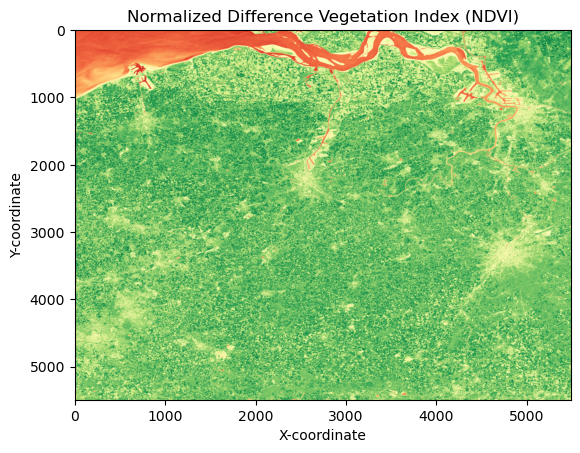

In [70]:
plt.imshow(ndvi,cmap='RdYlGn', vmin=-1, vmax=1)
plt.title('Normalized Difference Vegetation Index (NDVI)')
plt.xlabel('X-coordinate')
plt.ylabel('Y-coordinate')
plt.grid(False) # Turn off grid for image plots
plt.axis('tight') # Ensure axes fit the data tightly
# Display the plot
plt.show()

Clip this to the region of interest (Brussels):

In [71]:
type(ndvi)

xarray.core.dataarray.DataArray

In order to clip the NDVI to the ROI of Brussels, we first need to ensure that Coordinate Systems are the same.

In [72]:
gdf.crs

<Geographic 2D CRS: EPSG:4326>
Name: WGS 84
Axis Info [ellipsoidal]:
- Lat[north]: Geodetic latitude (degree)
- Lon[east]: Geodetic longitude (degree)
Area of Use:
- name: World.
- bounds: (-180.0, -90.0, 180.0, 90.0)
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

In [73]:
item_assets.keys()

dict_keys(['SR_10m', 'SR_20m', 'SR_60m', 'AOT_10m', 'B01_20m', 'B02_10m', 'B03_10m', 'B04_10m', 'B05_20m', 'B06_20m', 'B07_20m', 'B08_10m', 'B09_60m', 'B11_20m', 'B12_20m', 'B8A_20m', 'SCL_20m', 'TCI_10m', 'WVP_10m', 'product'])

In [74]:
s2_epsg = items_s2_filtered[1].properties['proj:code']
print(f'The Sentinel data is in {s2_epsg} projection')

The Sentinel data is in EPSG:32631 projection


In [75]:
# Code adapted from:
# https://www.geopythontutorials.com/notebooks/xarray_processing_satellite_images.html
geometry = gdf.to_crs(s2_epsg).geometry
geometry.crs

<Projected CRS: EPSG:32631>
Name: WGS 84 / UTM zone 31N
Axis Info [cartesian]:
- E[east]: Easting (metre)
- N[north]: Northing (metre)
Area of Use:
- name: Between 0°E and 6°E, northern hemisphere between equator and 84°N, onshore and offshore. Algeria. Andorra. Belgium. Benin. Burkina Faso. Denmark - North Sea. France. Germany - North Sea. Ghana. Luxembourg. Mali. Netherlands. Niger. Nigeria. Norway. Spain. Togo. United Kingdom (UK) - North Sea.
- bounds: (0.0, 0.0, 6.0, 84.0)
Coordinate Operation:
- name: UTM zone 31N
- method: Transverse Mercator
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

In [76]:
type(ndvi)
ndvi = ndvi.rio.write_crs("EPSG:4326", inplace=True)

In [77]:
ndvi_clipped = ndvi.rio.clip(geometry)

/opt/conda/lib/python3.12/site-packages/distributed/client.py:3374: UserWarning: Sending large graph of size 28.88 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(


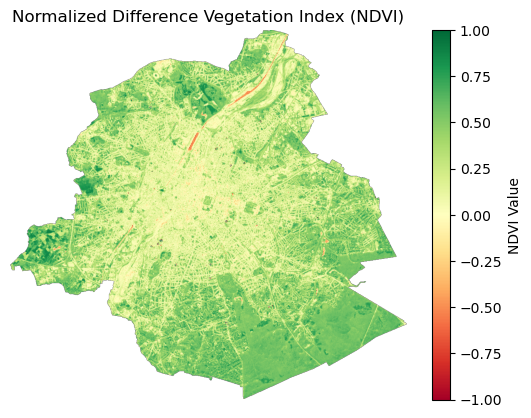

In [78]:
img = plt.imshow(ndvi_clipped, cmap='RdYlGn', vmin=-1, vmax=1)

plt.title('Normalized Difference Vegetation Index (NDVI)')
plt.grid(False)
plt.axis('tight')
plt.axis("off")

# Add color legend
cbar = plt.colorbar(img)
cbar.set_label("NDVI Value")

plt.show()

## TO DO: 

1. Try a different resolution for the Sentinel-2 bands such as 10 metres instead of 20 metres. 
2. Try other indices such as the Modified Normalised Difference Water Index. 
3. Use a different Region of Interest (ROI) of your choice. You can either use a GeoJson of a place of your choice or create a GeoJson using 
4. Experiment with the 

## Next steps

1. Combine the Sentinel-2 and Sentinel-3 data into one common grid and do some analytics on that (e.g. correlation, regression, etc).
2. Create a mosaic when the

## References

https://carpentries-incubator.github.io/geospatial-python/05-access-data.html

https://eopf-toolkit.github.io/eopf-101/04_eopf_and_stac/43_eopf_stac_connection.html

https://pystac-client.readthedocs.io/en/latest/tutorials/item-search-intersects.html

https://www.geopythontutorials.com/notebooks/xarray_processing_satellite_images.html

